# t-SNE 3D Feature-Space — Proposed Ensemble (Swin + ViT + ResNet50)
The ensemble combines predictions (softmax probabilities), not features, so
there's no single native "ensemble feature space". This notebook builds a
meaningful one by CONCATENATING the 256-dim embedding from each of the three
models (768-dim total) -- the joint representation the ensemble's decision
is actually built on -- and reduces it to 3D with t-SNE.

As a bonus (same session, no extra cost), it also plots each model's own
individual feature space for comparison, so you can see whether the combined
space separates classes better than any single model alone.

No TF_USE_LEGACY_KERAS needed (Swin + ViT + ResNet50 coexist fine, no LeViT).

## Cell 1 — Setup

In [1]:
!pip install -U keras-hub -q
!pip uninstall -y tensorflow-text keras-nlp -q
!pip install tfswin --no-deps -q

import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import tfswin
from tfswin import SwinTransformerTiny224
import keras_hub
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import logging
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("All imports successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
All imports successful!


## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set

In [3]:
split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Test folder ready: True


## Cell 4 — Load test CSV + config + datasets

In [4]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

def load_uint8(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)

def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img

def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_uint8 = make_ds(load_uint8)
test_ds_float32 = make_ds(load_float32)
print("Test samples:", len(test_df), "| Classes:", num_classes)

Test samples: 2538 | Classes: 12


## Cell 5 — Load Swin, ViT, ResNet50 + their feature extractors
For each model, a second Model object is built that shares the same layers
but stops at the 256-dim embedding (right before the final classification
Dense layer) -- loading weights into the full model updates both, since
they share the same underlying layer instances.

In [5]:
# --- Swin ---
swin_inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')
swin_base = SwinTransformerTiny224(include_top=False)
x = swin_base(swin_inputs)
x = layers.GlobalAveragePooling2D()(x)
swin_embedding = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(swin_embedding)
swin_outputs = layers.Dense(num_classes, activation='softmax')(x)
swin_model = models.Model(swin_inputs, swin_outputs)
swin_model.load_weights('/content/drive/MyDrive/thesis_swintiny_outputs/best_swintiny_model.keras')
swin_feature_model = models.Model(swin_inputs, swin_embedding)
print("Swin ready")

# --- ViT ---
vit_backbone = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
vit_backbone.trainable = False
vit_inputs = layers.Input(shape=(224, 224, 3), dtype='float32')
xn = layers.Lambda(lambda t: (t / 127.5) - 1.0)(vit_inputs)
xn = vit_backbone(xn)
cls_token = layers.Lambda(lambda t: t[:, 0, :])(xn)
vit_embedding = layers.Dense(256, activation='relu')(cls_token)
x = layers.Dropout(0.4)(vit_embedding)
vit_outputs = layers.Dense(num_classes, activation='softmax')(x)
vit_model = models.Model(vit_inputs, vit_outputs)
vit_model.load_weights('/content/drive/MyDrive/thesis_vit_outputs/best_vit_model.keras')
vit_feature_model = models.Model(vit_inputs, vit_embedding)
print("ViT ready")

# --- ResNet50 ---
resnet_zip_path = '/content/drive/MyDrive/thesis_resnet50_outputs-20260716T043630Z-1-001.zip'
if not os.path.exists('/content/resnet50_data'):
    with zipfile.ZipFile(resnet_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/resnet50_data')
resnet_model = load_model('/content/resnet50_data/thesis_resnet50_outputs/best_resnet50_model.keras')
# ResNet50 was loaded directly (not rebuilt), so grab its embedding layer by name/position:
# architecture is Input -> preprocess -> ResNet50 base -> GAP -> Dense(256, relu) -> Dropout -> Dense(softmax)
resnet_embedding_layer = resnet_model.layers[-3]   # the Dense(256, relu) layer
resnet_feature_model = models.Model(resnet_model.input, resnet_embedding_layer.output)
print("ResNet50 ready — embedding layer:", resnet_embedding_layer.name, resnet_embedding_layer.output.shape)

177485300/177485300 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Swin ready


100%|██████████| 909/909 [00:00<00:00, 927kB/s]


100%|██████████| 328M/328M [00:07<00:00, 45.3MB/s]


ViT ready
ResNet50 ready — embedding layer: dense (None, 256)


## Cell 6 — Sanity check: confirm the embedding-layer guess for ResNet50 is right
If this prints a Dense layer with 256 units, Cell 5's `layers[-3]` indexing
worked correctly. If not, adjust the index (try -4 or print `resnet_model.summary()`).

In [6]:
print("Last 5 layers of resnet_model:")
for layer in resnet_model.layers[-5:]:
    print(f"  {layer.name:30s} {layer.__class__.__name__:20s} output shape: {layer.output.shape}")

pred_swin_check = swin_model.predict(test_ds_uint8, verbose=1)
pred_vit_check = vit_model.predict(test_ds_float32, verbose=1)
pred_resnet_check = resnet_model.predict(test_ds_float32, verbose=1)

print(f"\nSwin accuracy:     {accuracy_score(true_labels, np.argmax(pred_swin_check, axis=1)):.4f}")
print(f"ViT accuracy:      {accuracy_score(true_labels, np.argmax(pred_vit_check, axis=1)):.4f}")
print(f"ResNet50 accuracy: {accuracy_score(true_labels, np.argmax(pred_resnet_check, axis=1)):.4f}")

ensemble_probs = (pred_swin_check + pred_vit_check + pred_resnet_check) / 3.0
print(f"Ensemble accuracy: {accuracy_score(true_labels, np.argmax(ensemble_probs, axis=1)):.4f}")

Last 5 layers of resnet_model:
  resnet50                       Functional           output shape: (None, 7, 7, 2048)
  global_average_pooling2d       GlobalAveragePooling2D output shape: (None, 2048)
  dense                          Dense                output shape: (None, 256)
  dropout                        Dropout              output shape: (None, 256)
  dense_1                        Dense                output shape: (None, 12)
80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 381ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 469ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step

Swin accuracy:     0.9842
ViT accuracy:      0.9823
ResNet50 accuracy: 0.9795
Ensemble accuracy: 0.9886


## Cell 7 — Extract embeddings from all three models, concatenate

In [7]:
emb_swin = swin_feature_model.predict(test_ds_uint8, verbose=1)
emb_vit = vit_feature_model.predict(test_ds_float32, verbose=1)
emb_resnet = resnet_feature_model.predict(test_ds_float32, verbose=1)

print("Swin embedding shape:", emb_swin.shape)
print("ViT embedding shape:", emb_vit.shape)
print("ResNet50 embedding shape:", emb_resnet.shape)

emb_concat = np.concatenate([emb_swin, emb_vit, emb_resnet], axis=1)
print("Concatenated (proposed ensemble) embedding shape:", emb_concat.shape)

80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 369ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 521ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step
Swin embedding shape: (2538, 256)
ViT embedding shape: (2538, 256)
ResNet50 embedding shape: (2538, 256)
Concatenated (proposed ensemble) embedding shape: (2538, 768)


## Cell 8 — Run t-SNE on the concatenated (ensemble) embedding

In [8]:
tsne_ensemble = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_3d_ensemble = tsne_ensemble.fit_transform(emb_concat)
print("t-SNE (ensemble) done:", embeddings_3d_ensemble.shape)

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)
np.save(f'{output_folder}/tsne_3d_ensemble.npy', embeddings_3d_ensemble)
np.save(f'{output_folder}/tsne_3d_labels.npy', true_labels)

t-SNE (ensemble) done: (2538, 3)


## Cell 9 — 3D plot: proposed ensemble's combined feature space

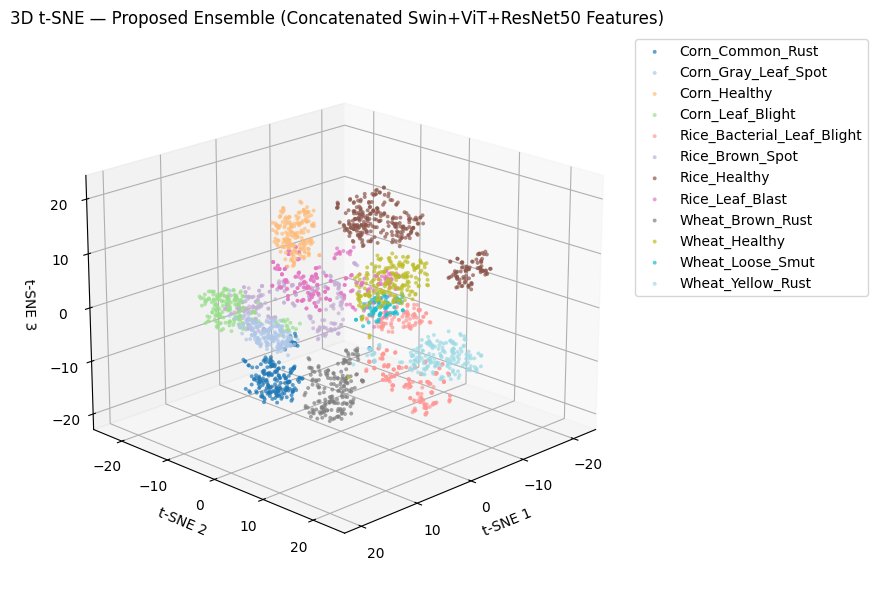

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/tsne_3d_ensemble.png


In [12]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
for i, cls in enumerate(class_names):
    mask = true_labels == i
    ax.scatter(embeddings_3d_ensemble[mask, 0], embeddings_3d_ensemble[mask, 1], embeddings_3d_ensemble[mask, 2],
               color=colors[i], label=cls, s=8, alpha=0.7, edgecolors='none')

ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.set_zlabel('t-SNE 3', fontsize=10)
ax.set_title('3D t-SNE — Proposed Ensemble (Concatenated Swin+ViT+ResNet50 Features)', fontsize=12)
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1.0), ncol=1)
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig(f'{output_folder}/tsne_3d_ensemble.png', dpi=250, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/tsne_3d_ensemble.png")

## Cell 10 (bonus) — Individual models' feature spaces, for comparison
Same t-SNE treatment applied to each model's own embedding alone -- lets you
see whether the combined (ensemble) space separates classes more cleanly
than any single model.

Swin t-SNE done
ViT t-SNE done
ResNet50 t-SNE done


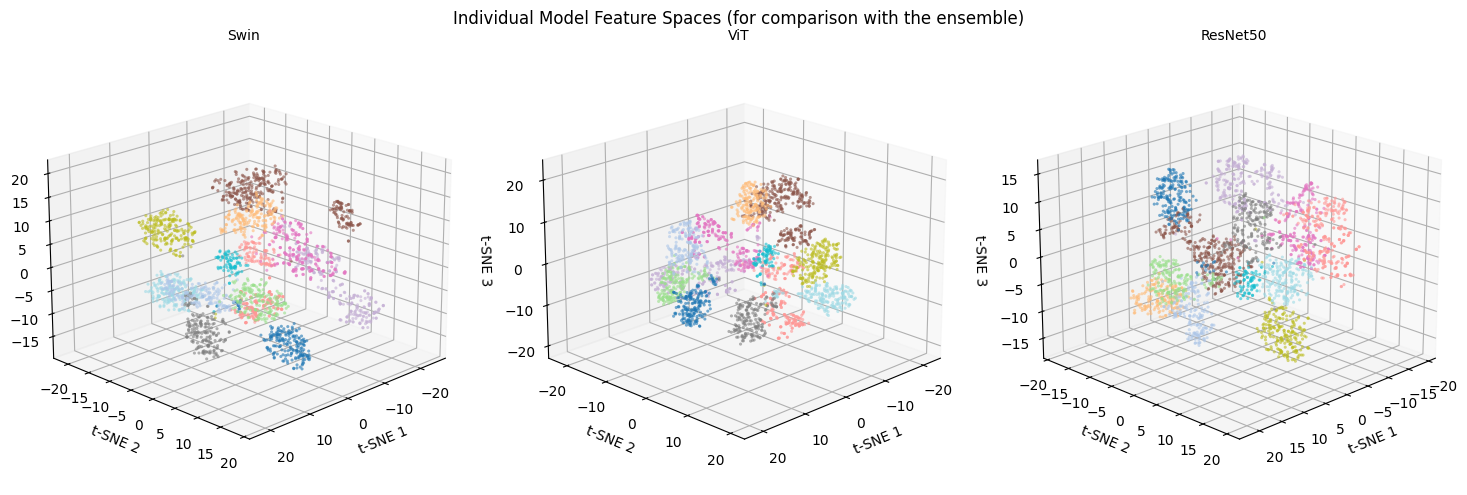

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/tsne_3d_individual_models.png


In [13]:
individual_embeddings = {"Swin": emb_swin, "ViT": emb_vit, "ResNet50": emb_resnet}
individual_3d = {}

for name, emb in individual_embeddings.items():
    tsne = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    individual_3d[name] = tsne.fit_transform(emb)
    print(f"{name} t-SNE done")

fig = plt.figure(figsize=(15, 5))
for idx, (name, coords) in enumerate(individual_3d.items()):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    for i, cls in enumerate(class_names):
        mask = true_labels == i
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   color=colors[i], s=5, alpha=0.6, edgecolors='none')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.set_zlabel('t-SNE 3', fontsize=10)
    ax.view_init(elev=20, azim=45)

plt.suptitle('Individual Model Feature Spaces (for comparison with the ensemble)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_folder}/tsne_3d_individual_models.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/tsne_3d_individual_models.png")